**Extreme Value Theory - Peaks Over Tails Modelling of Tail Risk Using Generalized Pareto Distribution**

In [1]:
# Importing Libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy
import seaborn as sns
from scipy.stats import genpareto
from statsmodels.tsa.stattools import adfuller

In [2]:
# Downloading Data
data = yf.download('^NSEI', start = '2018-01-01', end = '2025-01-01')['Close']
data.columns = ['Close Price']
data = data.reset_index()
data = data.set_index('Date')
data['Log Returns'] = np.log(data['Close Price'] / data['Close Price'].shift(1))
data['Losses'] = -data['Log Returns']
data.dropna(inplace = True)
data.head()

C:\Users\Souradeep\AppData\Local\Temp\ipykernel_4800\2495431029.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('^NSEI', start = '2018-01-01', end = '2025-01-01')['Close']
[*********************100%***********************]  1 of 1 completed


,Close Price,Log Returns,Losses
Date,,,
2018-01-03,10443.200195,0.000096,-0.000096
2018-01-04,10504.799805,0.005881,-0.005881
2018-01-05,10558.849609,0.005132,-0.005132
2018-01-08,10623.599609,0.006114,-0.006114
2018-01-09,10637.000000,0.001261,-0.001261


In [3]:
# ADF Test For Log Returns Stationarity
result = adfuller(data['Log Returns'])
print(f"ADF Test Statistic: {result[0]}")
print(f"p-value: {result[1]}")

ADF Test Statistic: -12.023872750742262
p-value: 2.980042442918885e-22


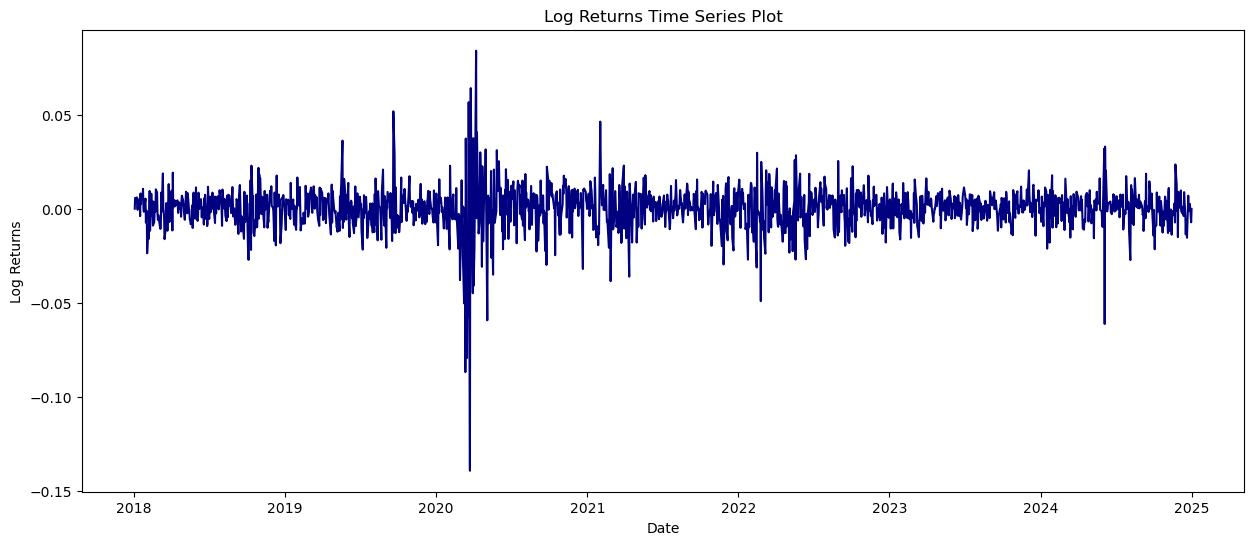

In [4]:
# Plot of Log Returns 
plt.figure(figsize = (15, 6))
plt.plot(data['Log Returns'], color = 'navy')
plt.xlabel("Date")
plt.title("Log Returns Time Series Plot")
plt.ylabel("Log Returns")
plt.show()

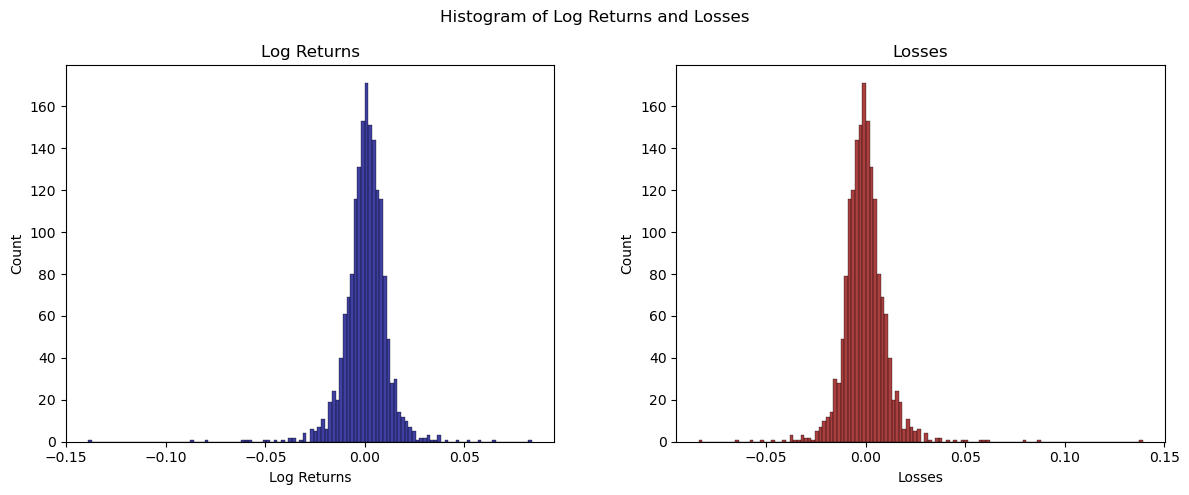

In [5]:
# Histogram of Log Returns and Losses
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].set_title("Log Returns")
sns.histplot(data['Log Returns'], color='navy', ax=axes[0])
axes[1].set_title("Losses")
sns.histplot(data['Losses'], color='darkred', ax=axes[1])
fig.suptitle("Histogram of Log Returns and Losses")
plt.tight_layout()
plt.subplots_adjust(wspace=0.25)

plt.show()

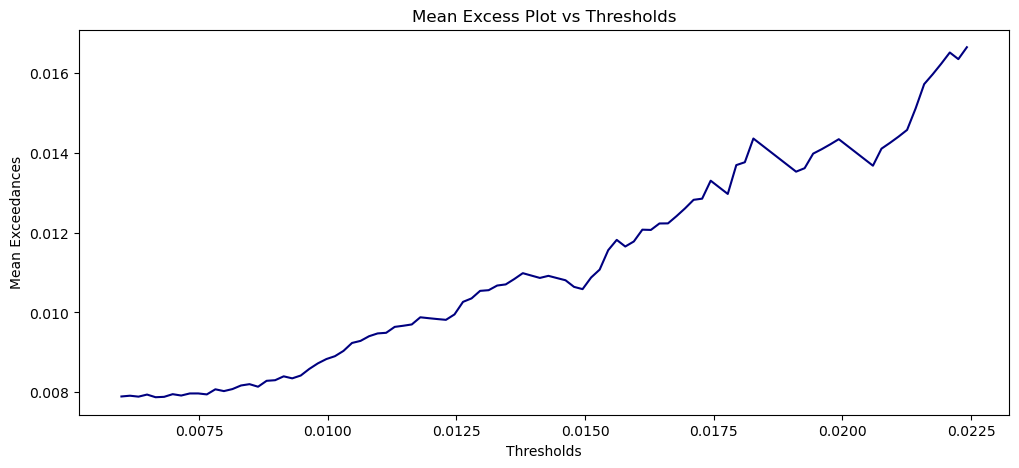

In [6]:
# ME Plot For Percentile Loss Thresholds
plt.figure(figsize = (12, 5))
thresholds = np.linspace(np.percentile(data['Losses'], 80), np.percentile(data['Losses'], 98), 100)
mean_excess = []
for i in thresholds:
   excess = data['Losses'][data['Losses'] > i] - i
   mean_excess.append(excess.mean())
plt.plot(thresholds, mean_excess, color = 'navy')
plt.xlabel("Thresholds")
plt.title("Mean Excess Plot vs Thresholds")
plt.ylabel("Mean Exceedances")
plt.show()

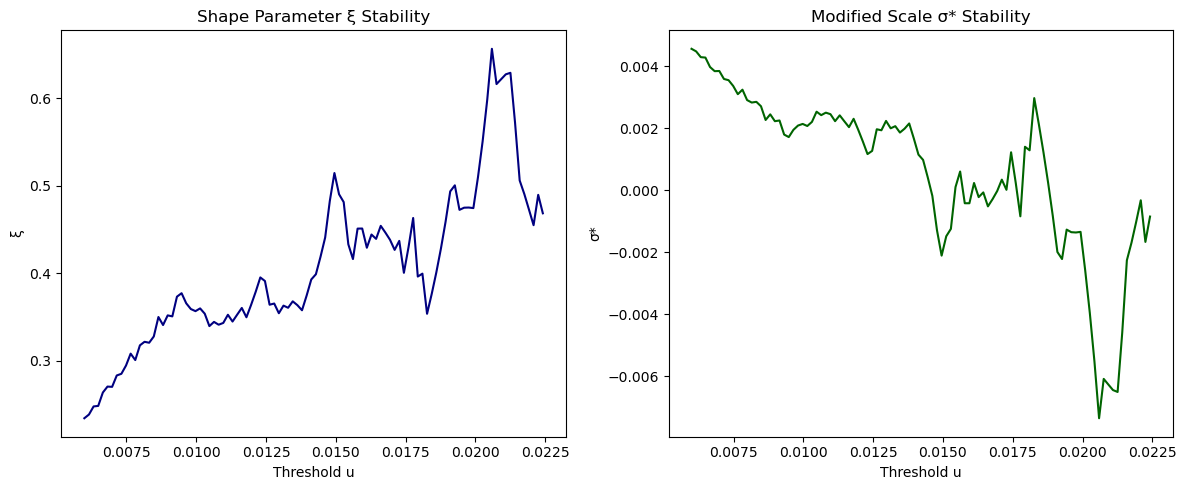

In [7]:
# Selecting Optimal Threshold For Parameter Stability
xi_list = []
sigma_list = []
threshold_list = []
for i in thresholds:
    excess = data['Losses'][data['Losses'] > i] - i
    xi_i, loc_i, sigma_i = genpareto.fit(excess, floc=0)
    sigma_star = sigma_i - xi_i * i
    xi_list.append(xi_i)
    sigma_list.append(sigma_star)
    threshold_list.append(i)

plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)
plt.plot(threshold_list, xi_list, color='navy')
plt.title('Shape Parameter ξ Stability')
plt.xlabel('Threshold u')
plt.ylabel('ξ')

plt.subplot(1,2,2)
plt.plot(threshold_list, sigma_list, color='darkgreen')
plt.title('Modified Scale σ* Stability')
plt.xlabel('Threshold u')
plt.ylabel('σ*')

plt.tight_layout()
plt.show()

In [8]:
## Fitting GPD on Optimal Threshold
u = np.percentile(data['Losses'], 87)
excess = data['Losses'][(data['Losses'] > u)] - u
xi, loc, sigma = scipy.stats.genpareto.fit(excess, floc = 0)
print("Xi: ", xi)
print("Loc: ", loc)
print("Sigma: ", sigma)

Xi:  0.345751868898029
Loc:  0
Sigma:  0.005459375475782963


In [9]:
# Computing VaR and CVaR at Confidence levels
Nu = len(excess)
N = len(data['Losses'])
zeta = Nu/N
VAR = []
CVAR = []
for p in [0.90, 0.95, 0.99]:
    var = u + (sigma/xi) * ((((1 - p) / zeta) ** (-xi)) - 1)
    VAR.append(var)
    cvar = (var + sigma - (xi * u)) / (1 - xi)
    CVAR.append(cvar)

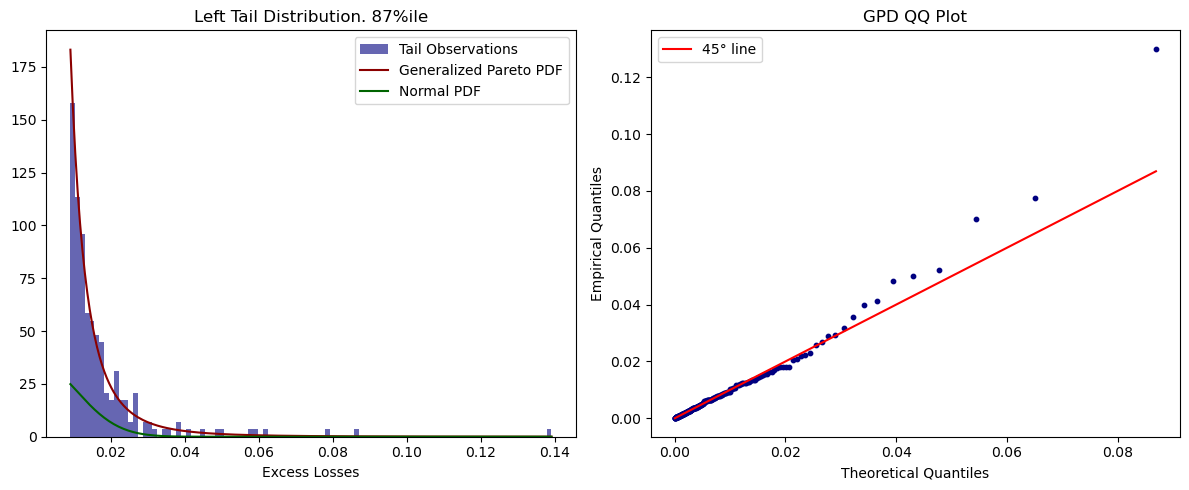

In [10]:
# Plotting GPD vs Normal PDF and QQ Plot
x = np.linspace(u, data['Losses'].max(), 200)
gpd_pdf = scipy.stats.genpareto.pdf(x - u, xi, loc=0, scale=sigma)
mu, std = data['Losses'].mean(), data['Losses'].std()
normal_pdf = scipy.stats.norm.pdf(x, mu, std)
n = len(excess)
empirical = np.sort(excess)
theoretical = genpareto.ppf(np.arange(1, n + 1) / (n + 1), xi, loc=0, scale=sigma)

plt.figure(figsize = (12, 5))

plt.subplot(1,2,1)
plt.hist(data['Losses'][data['Losses'] > u], bins=100, color = 'navy', density=True, alpha=0.6, label='Tail Observations')
plt.plot(x, gpd_pdf, color='darkred', label='Generalized Pareto PDF')
plt.plot(x, normal_pdf, color='darkgreen', label='Normal PDF')
plt.xlabel('Excess Losses')
plt.title(f'Left Tail Distribution. {87}%ile')
plt.legend()

plt.subplot(1,2,2)
plt.scatter(theoretical, empirical, s=10, color='navy')
plt.plot([theoretical.min(), theoretical.max()],
         [theoretical.min(), theoretical.max()], color = 'red', label='45° line')
plt.title('GPD QQ Plot')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Empirical Quantiles')
plt.legend()
plt.tight_layout()
plt.show()

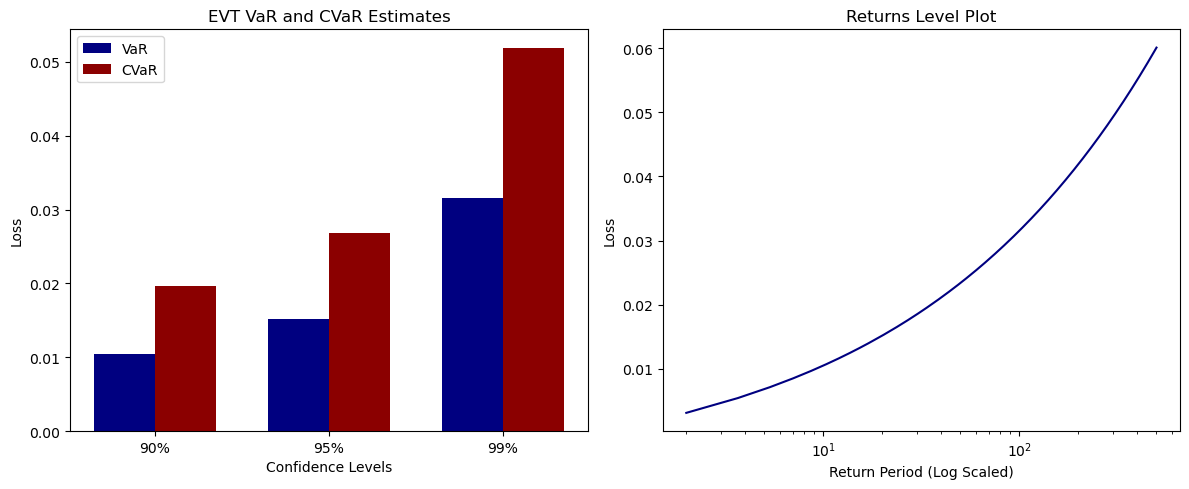

In [11]:
# Plotting VaR and CVaR for Cofidence Levels and Returns Plot
plt.figure(figsize = (12, 5))
plt.subplot(1,2,1)
levels = ['90%', '95%', '99%']
x = np.arange(len(levels))
width = 0.35
plt.bar(x - width/2, [j for j in VAR], width, color='navy', label='VaR')
plt.bar(x + width/2, [k for k in CVAR], width, color='darkred', label='CVaR')
plt.xticks(x, levels)
plt.title('EVT VaR and CVaR Estimates')
plt.ylabel('Loss')
plt.xlabel("Confidence Levels")
plt.legend()
plt.tight_layout()

plt.subplot(1,2,2)
return_periods = np.linspace(2, 500, 300)
p_levels = 1 - 1 / return_periods
return_levels = u + (sigma / xi) * (((1 - p_levels) / zeta) ** (-xi) - 1)
plt.plot(return_periods, return_levels, color='navy')
plt.xscale('log')
plt.title('Returns Level Plot')
plt.xlabel('Return Period (Log Scaled)')
plt.ylabel('Loss')
plt.tight_layout()
plt.show()